In [2]:
pip install cartopy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 1.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 32.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 31.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.7 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from netCDF4 import Dataset
import os

import cartopy.crs as crs
import cartopy.feature as cfeature

import warnings
warnings.filterwarnings("ignore")


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
# Read Ian data

df_data_Ian = pd.read_csv('Ian_hydro.csv', low_memory=False).dropna()
stations = df_data_Ian['station_id'].unique()
print('Total no. of stations:', len(stations))


Total no. of stations: 263


In [3]:
df_data_Ian.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41764 entries, 0 to 41763
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time_UTC       41764 non-null  object 
 1   observed_data  41764 non-null  float64
 2   forecast_data  41764 non-null  float64
 3   offset         41764 non-null  float64
 4   x              41764 non-null  float64
 5   y              41764 non-null  float64
 6   station_id     41764 non-null  int64  
 7   agency         41764 non-null  object 
 8   storm          41764 non-null  object 
 9   year           41764 non-null  int64  
 10  time_UTC_dt    41764 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 3.5+ MB


In [4]:
df_data_Ian['agency'].unique()

array(['USGS', 'USACE', 'NOAA_NOS', 'TCOON'], dtype=object)

In [5]:
# Load grid

grid_dir = r'G:\Documents\LSU\ADCIRC_files\Hurricane_Ian\maxele.63.nc'

ds=Dataset(grid_dir)
x_grid = ds['x'][:]
y_grid = ds['y'][:]


FileNotFoundError: [Errno 2] No such file or directory: 'G:\\Documents\\LSU\\ADCIRC_files\\Hurricane_Ian\\maxele.63.nc'

In [6]:
target = stations[1]
df_data_Ian[df_data_Ian['station_id']==target]['agency'].dropna().unique()[0]

'USGS'

In [7]:
# Correlate offsets

station = stations[0]

# df_data_Ian[df_data['station_id']==station]['offset']

corr_mat = np.ones([len(stations)-1,4])*np.nan
for count, target in enumerate(stations[1:]):
    corr_mat[count, 0] = df_data_Ian[df_data_Ian['station_id']==station]['offset'].reset_index(drop=True).corr(df_data_Ian[df_data_Ian['station_id']==target]['offset'].reset_index(drop=True))
    corr_mat[count, 1] = df_data_Ian[df_data_Ian['station_id']==target]['x'].dropna().unique()[0]
    corr_mat[count, 2] = df_data_Ian[df_data_Ian['station_id']==target]['y'].dropna().unique()[0]
    agency = df_data_Ian[df_data_Ian['station_id']==target]['agency'].dropna().unique()[0]
    if agency == 'NOAA_NOS' or agency == 'TCOON':
        corr_mat[count, 3] = 1
    else:
        corr_mat[count, 3] = 0

corr_mat_NOAA = corr_mat[corr_mat[:, 3] == 1]
corr_mat_USGS = corr_mat[corr_mat[:, 3] == 0]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [9]:
corr_mat.shape

(262, 4)

In [8]:
df_stations_info = pd.read_csv('stations_Ian.csv')
print(df_stations_info[(df_stations_info['agency'] == 'USGS') | (df_stations_info['agency'] == 'USACE')].dropna().shape[0])
print((corr_mat[:, 3] == 1).sum())
print(np.unique(corr_mat[:, 3]))

124
139
[0. 1.]


In [9]:
# print(corr_mat[])

USGS


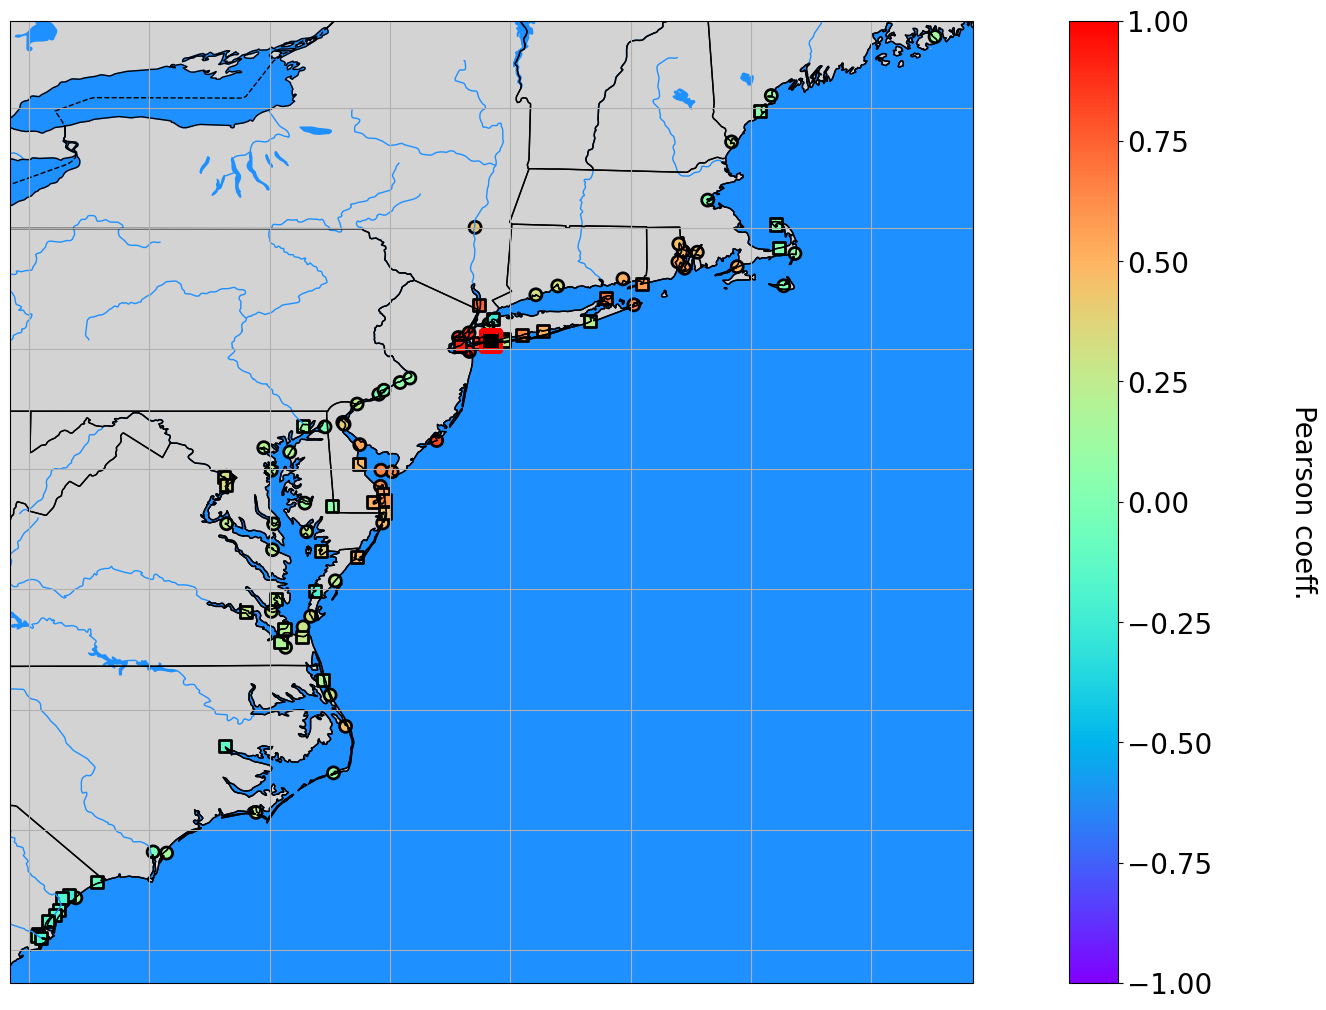

In [36]:
plt.rcParams['figure.figsize'] = [25, 12.5]
plt.rcParams.update({'font.size': 20})

fig = plt.figure()
ax = fig.add_subplot(1,1,1, projection=crs.PlateCarree())
# fig, ax = plt.subplots()
ax.set_global()
# ax.stock_img()
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, edgecolor="black")
ax.add_feature(cfeature.LAND, color="lightgrey")
ax.add_feature(cfeature.LAKES, color="dodgerblue")
ax.add_feature(cfeature.BORDERS, linestyle="--")
ax.add_feature(cfeature.OCEAN, color="dodgerblue")
ax.add_feature(cfeature.RIVERS, color="dodgerblue")
ax.add_feature(cfeature.STATES)
ax.gridlines()
# im0 = ax.scatter(x_grid, y_grid, s=1)
im1 = ax.scatter(corr_mat_NOAA[:,1], corr_mat_NOAA[:,2], c=corr_mat_NOAA[:,0],
                 linewidth=2, cmap='rainbow', vmin=-1, vmax=1, edgecolors='black', s=75, alpha=1.0)
im2 = ax.scatter(corr_mat_USGS[:,1], corr_mat_USGS[:,2], c=corr_mat_USGS[:,0],
                  linewidth=2, cmap='rainbow', vmin=-1, vmax=1, marker = 's', edgecolors='black', s=75, alpha=1.0)
im3 = ax.scatter(corr_mat[:,1], corr_mat[:,2], c=corr_mat[:,0], cmap='rainbow', vmin=-1, vmax=1, edgecolors='black', s=150)
im3.set_visible(False)
x = df_data_Ian[df_data_Ian['station_id']==station]['x'].unique()[0]
y = df_data_Ian[df_data_Ian['station_id']==station]['y'].unique()[0]
agency = df_data_Ian[df_data_Ian['station_id']==station]['agency'].dropna().unique()[0]
print(agency)
if (agency == 'NOAA_NOS') | (agency == 'TCOON'):
    im4 = ax.scatter(x, y, c='black', linewidth=3, edgecolors='red', s=200, alpha=1.0)
else:
    im4 = ax.scatter(x, y, c='black', linewidth=3, marker='s', edgecolors='red', s=200, alpha=1.0)


plt.xlim((x-6, x+6))
plt.ylim((y-8, y+4))

# ax.set_title(str(storm))
# ax.get_xaxis().set_visible(False)
# ax.get_yaxis().set_visible(False)




cbar = fig.colorbar(im3, ax=ax)
cbar.ax.get_yaxis().labelpad = 75
cbar.ax.set_ylabel('Pearson coeff.', rotation=270)

# plt.savefig("Ian-hydrographs_grid.png", facecolor='white', edgecolor='none')
# save_path = os.path.join('max_offsets_without_filtering', storm)
# save_str = save_path + str(storm)
# plt.savefig(save_path)
# plt.close(fig)
plt.show()

In [37]:
# Correlate offsets

if not os.path.exists('Ian_offsets_correlation_zoom'):
   os.makedirs('Ian_offsets_correlation_zoom')

for station in stations:
    print('Plotting for station id: ', station)
    corr_mat = np.ones([len(stations),4])*np.nan
    for count, target in enumerate(stations):
        if target == station:
            continue
        corr_mat[count, 0] = df_data_Ian[df_data_Ian['station_id']==station]['offset'].reset_index(drop=True).corr(df_data_Ian[df_data_Ian['station_id']==target]['offset'].reset_index(drop=True))
        corr_mat[count, 1] = df_data_Ian[df_data_Ian['station_id']==target]['x'].dropna().unique()[0]
        corr_mat[count, 2] = df_data_Ian[df_data_Ian['station_id']==target]['y'].dropna().unique()[0]
        agency = df_data_Ian[df_data_Ian['station_id']==target]['agency'].dropna().unique()[0]
        if agency == 'NOAA_NOS' or agency == 'TCOON':
            corr_mat[count, 3] = 1
        else:
            corr_mat[count, 3] = 0

    corr_mat_NOAA = corr_mat[corr_mat[:, 3] == 1]
    corr_mat_USGS = corr_mat[corr_mat[:, 3] == 0]
     
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1, projection=crs.PlateCarree())
    # fig, ax = plt.subplots()
    ax.set_global()
    # ax.stock_img()
    ax.add_feature(cfeature.COASTLINE, edgecolor="black")
    ax.add_feature(cfeature.BORDERS, edgecolor="black")
    ax.add_feature(cfeature.LAND, color="lightgrey")
    ax.add_feature(cfeature.LAKES, color="dodgerblue")
    ax.add_feature(cfeature.BORDERS, linestyle="--")
    ax.add_feature(cfeature.OCEAN, color="dodgerblue")
    ax.add_feature(cfeature.RIVERS, color="dodgerblue")
    ax.add_feature(cfeature.STATES)
    ax.gridlines()
    # im0 = ax.scatter(x_grid, y_grid, s=1)
    im1 = ax.scatter(corr_mat_NOAA[:,1], corr_mat_NOAA[:,2], c=corr_mat_NOAA[:,0],
                    linewidth=2, cmap='rainbow', vmin=-1, vmax=1, edgecolors='black', s=75, alpha=1.0)
    im2 = ax.scatter(corr_mat_USGS[:,1], corr_mat_USGS[:,2], c=corr_mat_USGS[:,0],
                    linewidth=2, cmap='rainbow', vmin=-1, vmax=1, marker = 's', edgecolors='black', s=75, alpha=1.0)
    im3 = ax.scatter(corr_mat[:,1], corr_mat[:,2], c=corr_mat[:,0], cmap='rainbow', vmin=-1, vmax=1, edgecolors='black', s=150)
    im3.set_visible(False)
    x = df_data_Ian[df_data_Ian['station_id']==station]['x'].unique()[0]
    y = df_data_Ian[df_data_Ian['station_id']==station]['y'].unique()[0]
    agency = df_data_Ian[df_data_Ian['station_id']==station]['agency'].dropna().unique()[0]
    if (agency == 'NOAA_NOS') | (agency == 'TCOON'):
        im4 = ax.scatter(x, y, c='black', linewidth=3, edgecolors='red', s=200, alpha=1.0)
    else:
        im4 = ax.scatter(x, y, c='black', linewidth=3, marker='s', edgecolors='red', s=200, alpha=1.0)


    plt.xlim((x-6, x+6))
    plt.ylim((y-8, y+4))

    cbar = fig.colorbar(im3, ax=ax)
    cbar.ax.get_yaxis().labelpad = 75
    cbar.ax.set_ylabel('Pearson coeff.', rotation=270)
    save_path = os.path.join('Ian_offsets_correlation_zoom', str(station))
    save_str = save_path + '.png'
    plt.savefig(save_path, bbox_inches='tight')
    plt.close(fig)



Plotting for station id:  1302250
Plotting for station id:  1304200
Plotting for station id:  1304746
Plotting for station id:  1306402
Plotting for station id:  1309225
Plotting for station id:  1310521
Plotting for station id:  1310740
Plotting for station id:  1311145
Plotting for station id:  1311875
Plotting for station id:  1376269
Plotting for station id:  1376562
Plotting for station id:  1484085
Plotting for station id:  1484540
Plotting for station id:  1484670
Plotting for station id:  1484683
Plotting for station id:  1484701
Plotting for station id:  1484746
Plotting for station id:  1484812
Plotting for station id:  1485755
Plotting for station id:  1488110
Plotting for station id:  1545
Plotting for station id:  1580620
Plotting for station id:  1647600
Plotting for station id:  165258890
Plotting for station id:  1670
Plotting for station id:  1670060
Plotting for station id:  1850
Plotting for station id:  2042770
Plotting for station id:  2042893
Plotting for station 

In [38]:
# Correlate predicted water levels


if not os.path.exists('Ian_forecast_correlation_zoom'):
   os.makedirs('Ian_forecast_correlation_zoom')


for station in stations:
    print('Plotting for station id: ', station)
    corr_mat = np.ones([len(stations),4])*np.nan
    for count, target in enumerate(stations):
        if target == station:
            continue
        corr_mat[count, 0] = df_data_Ian[df_data_Ian['station_id']==station]['forecast_data'].reset_index(drop=True).corr(df_data_Ian[df_data_Ian['station_id']==target]['forecast_data'].reset_index(drop=True))
        corr_mat[count, 1] = df_data_Ian[df_data_Ian['station_id']==target]['x'].dropna().unique()[0]
        corr_mat[count, 2] = df_data_Ian[df_data_Ian['station_id']==target]['y'].dropna().unique()[0]
        agency = df_data_Ian[df_data_Ian['station_id']==target]['agency'].dropna().unique()[0]
        if agency == 'NOAA_NOS' or agency == 'TCOON':
            corr_mat[count, 3] = 1
        else:
            corr_mat[count, 3] = 0

    corr_mat_NOAA = corr_mat[corr_mat[:, 3] == 1]
    corr_mat_USGS = corr_mat[corr_mat[:, 3] == 0]
     
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1, projection=crs.PlateCarree())
    # fig, ax = plt.subplots()
    ax.set_global()
    # ax.stock_img()
    ax.add_feature(cfeature.COASTLINE, edgecolor="black")
    ax.add_feature(cfeature.BORDERS, edgecolor="black")
    ax.add_feature(cfeature.LAND, color="lightgrey")
    ax.add_feature(cfeature.LAKES, color="dodgerblue")
    ax.add_feature(cfeature.BORDERS, linestyle="--")
    ax.add_feature(cfeature.OCEAN, color="dodgerblue")
    ax.add_feature(cfeature.RIVERS, color="dodgerblue")
    ax.add_feature(cfeature.STATES)
    ax.gridlines()
    # im0 = ax.scatter(x_grid, y_grid, s=1)
    im1 = ax.scatter(corr_mat_NOAA[:,1], corr_mat_NOAA[:,2], c=corr_mat_NOAA[:,0],
                    linewidth=2, cmap='rainbow', vmin=-1, vmax=1, edgecolors='black', s=75, alpha=1.0)
    im2 = ax.scatter(corr_mat_USGS[:,1], corr_mat_USGS[:,2], c=corr_mat_USGS[:,0],
                    linewidth=2, cmap='rainbow', vmin=-1, vmax=1, marker = 's', edgecolors='black', s=75, alpha=1.0)
    im3 = ax.scatter(corr_mat[:,1], corr_mat[:,2], c=corr_mat[:,0], cmap='rainbow', vmin=-1, vmax=1, edgecolors='black', s=150)
    im3.set_visible(False)
    x = df_data_Ian[df_data_Ian['station_id']==station]['x'].unique()[0]
    y = df_data_Ian[df_data_Ian['station_id']==station]['y'].unique()[0]
    agency = df_data_Ian[df_data_Ian['station_id']==station]['agency'].dropna().unique()[0]
    if (agency == 'NOAA_NOS') | (agency == 'TCOON'):
        im4 = ax.scatter(x, y, c='black', linewidth=3, edgecolors='red', s=200, alpha=1.0)
    else:
        im4 = ax.scatter(x, y, c='black', linewidth=3, marker='s', edgecolors='red', s=200, alpha=1.0)


    plt.xlim((x-6, x+6))
    plt.ylim((y-8, y+4))

    cbar = fig.colorbar(im3, ax=ax)
    cbar.ax.get_yaxis().labelpad = 75
    cbar.ax.set_ylabel('Pearson coeff.', rotation=270)
    save_path = os.path.join('Ian_forecast_correlation_zoom', str(station))
    save_str = save_path + '.png'
    plt.savefig(save_path, bbox_inches='tight')
    plt.close(fig)


Plotting for station id:  1302250
Plotting for station id:  1304200
Plotting for station id:  1304746
Plotting for station id:  1306402
Plotting for station id:  1309225
Plotting for station id:  1310521
Plotting for station id:  1310740
Plotting for station id:  1311145
Plotting for station id:  1311875
Plotting for station id:  1376269
Plotting for station id:  1376562
Plotting for station id:  1484085
Plotting for station id:  1484540
Plotting for station id:  1484670
Plotting for station id:  1484683
Plotting for station id:  1484701
Plotting for station id:  1484746
Plotting for station id:  1484812
Plotting for station id:  1485755
Plotting for station id:  1488110
Plotting for station id:  1545
Plotting for station id:  1580620
Plotting for station id:  1647600
Plotting for station id:  165258890
Plotting for station id:  1670
Plotting for station id:  1670060
Plotting for station id:  1850
Plotting for station id:  2042770
Plotting for station id:  2042893
Plotting for station 

In [40]:
# Correlate observed water levels


if not os.path.exists('Ian_observed_correlation_zoom'):
   os.makedirs('Ian_observed_correlation_zoom')


for station in stations:
    print('Plotting for station id: ', station)
    corr_mat = np.ones([len(stations),4])*np.nan
    for count, target in enumerate(stations):
        if target == station:
            continue
        corr_mat[count, 0] = df_data_Ian[df_data_Ian['station_id']==station]['observed_data'].reset_index(drop=True).corr(df_data_Ian[df_data_Ian['station_id']==target]['observed_data'].reset_index(drop=True))
        corr_mat[count, 1] = df_data_Ian[df_data_Ian['station_id']==target]['x'].dropna().unique()[0]
        corr_mat[count, 2] = df_data_Ian[df_data_Ian['station_id']==target]['y'].dropna().unique()[0]
        agency = df_data_Ian[df_data_Ian['station_id']==target]['agency'].dropna().unique()[0]
        if agency == 'NOAA_NOS' or agency == 'TCOON':
            corr_mat[count, 3] = 1
        else:
            corr_mat[count, 3] = 0

    corr_mat_NOAA = corr_mat[corr_mat[:, 3] == 1]
    corr_mat_USGS = corr_mat[corr_mat[:, 3] == 0]
     
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1, projection=crs.PlateCarree())
    # fig, ax = plt.subplots()
    ax.set_global()
    # ax.stock_img()
    ax.add_feature(cfeature.COASTLINE, edgecolor="black")
    ax.add_feature(cfeature.BORDERS, edgecolor="black")
    ax.add_feature(cfeature.LAND, color="lightgrey")
    ax.add_feature(cfeature.LAKES, color="dodgerblue")
    ax.add_feature(cfeature.BORDERS, linestyle="--")
    ax.add_feature(cfeature.OCEAN, color="dodgerblue")
    ax.add_feature(cfeature.RIVERS, color="dodgerblue")
    ax.add_feature(cfeature.STATES)
    ax.gridlines()
    # im0 = ax.scatter(x_grid, y_grid, s=1)
    im1 = ax.scatter(corr_mat_NOAA[:,1], corr_mat_NOAA[:,2], c=corr_mat_NOAA[:,0],
                    linewidth=2, cmap='rainbow', vmin=-1, vmax=1, edgecolors='black', s=75, alpha=1.0)
    im2 = ax.scatter(corr_mat_USGS[:,1], corr_mat_USGS[:,2], c=corr_mat_USGS[:,0],
                    linewidth=2, cmap='rainbow', vmin=-1, vmax=1, marker = 's', edgecolors='black', s=75, alpha=1.0)
    im3 = ax.scatter(corr_mat[:,1], corr_mat[:,2], c=corr_mat[:,0], cmap='rainbow', vmin=-1, vmax=1, edgecolors='black', s=150)
    im3.set_visible(False)
    x = df_data_Ian[df_data_Ian['station_id']==station]['x'].unique()[0]
    y = df_data_Ian[df_data_Ian['station_id']==station]['y'].unique()[0]
    agency = df_data_Ian[df_data_Ian['station_id']==station]['agency'].dropna().unique()[0]
    if (agency == 'NOAA_NOS') | (agency == 'TCOON'):
        im4 = ax.scatter(x, y, c='black', linewidth=3, edgecolors='red', s=200, alpha=1.0)
    else:
        im4 = ax.scatter(x, y, c='black', linewidth=3, marker='s', edgecolors='red', s=200, alpha=1.0)


    plt.xlim((x-6, x+6))
    plt.ylim((y-8, y+4))

    cbar = fig.colorbar(im3, ax=ax)
    cbar.ax.get_yaxis().labelpad = 75
    cbar.ax.set_ylabel('Pearson coeff.', rotation=270)
    save_path = os.path.join('Ian_observed_correlation_zoom', str(station))
    save_str = save_path + '.png'
    plt.savefig(save_path, bbox_inches='tight')
    plt.close(fig)
    # plt.show()



Plotting for station id:  1302250
Plotting for station id:  1304200
Plotting for station id:  1304746
Plotting for station id:  1306402
Plotting for station id:  1309225
Plotting for station id:  1310521
Plotting for station id:  1310740
Plotting for station id:  1311145
Plotting for station id:  1311875
Plotting for station id:  1376269
Plotting for station id:  1376562
Plotting for station id:  1484085
Plotting for station id:  1484540
Plotting for station id:  1484670
Plotting for station id:  1484683
Plotting for station id:  1484701
Plotting for station id:  1484746
Plotting for station id:  1484812
Plotting for station id:  1485755
Plotting for station id:  1488110
Plotting for station id:  1545
Plotting for station id:  1580620
Plotting for station id:  1647600
Plotting for station id:  165258890
Plotting for station id:  1670
Plotting for station id:  1670060
Plotting for station id:  1850
Plotting for station id:  2042770
Plotting for station id:  2042893
Plotting for station 